# 04 — Univariate Feature Analysis

One feature at a time: the shape of each engineered feature's distribution. This is where computation bugs surface — a bounded indicator that escapes its bounds, a volatility that goes negative, a distribution that is all zeros — long before a model would quietly swallow them.

Sections:
1. **Grid overview** — every feature at a glance
2. **Sanity-range checks** — features that should live in known bounds, flagged if they escape
3. **Per-family detail** — distributions grouped by feature type, with KDE
4. **Per-sector breakdown** — how a feature's distribution shifts across sectors
5. **Targets** — the labels' own distributions

Reads the **processed** feature table, so run the feature pipeline first.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES, TARGET_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,month,quarter,ticker_id,sector_id,sector_avg_return_20d,relative_strength_sector_20d,days_to_next_earnings,future_return,future_direction,future_realized_vol
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,7,3,0,5,NaN,NaN,29.0,0.017930,1,0.011389
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,7,3,0,5,NaN,NaN,28.0,0.004344,1,0.010595
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,7,3,0,5,NaN,NaN,27.0,0.016711,1,0.011089
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,7,3,0,5,NaN,NaN,26.0,0.015645,1,0.010962
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,7,3,0,5,NaN,NaN,25.0,0.006022,1,0.009477


In [3]:
features = [c for c in FEATURE_NAMES if c in data.columns and data[c].notna().any()]
targets = [c for c in TARGET_NAMES if c in data.columns]
print(f"rows: {len(data):,}   features present: {len(features)}")

rows: 622,731   features present: 42


In [4]:
FEATURE_FAMILIES = {
    "Trend": [
        "sma_10", "sma_20", "sma_50", "sma_200", "ema_12", "ema_26",
        "macd", "macd_signal", "macd_hist", "price_to_sma_50",
    ],
    "Momentum": ["rsi_14", "stoch_k_14", "stoch_d_3", "roc_5", "roc_10"],
    "Volatility": [
        "atr_14", "bb_width_20", "bb_percent_b_20",
        "log_return_std_10", "log_return_std_20",
        "realized_vol_10_annualized", "realized_vol_20_annualized",
    ],
    "Volume": ["obv_change_5", "volume_to_sma_20", "price_to_vwap", "vwap_20"],
    "Autoregressive": [
        "log_return_lag_1d", "log_return_lag_2d", "log_return_lag_3d",
        "log_return_lag_4d", "log_return_lag_5d",
        "volatility_lag_1d", "volatility_lag_5d", "return_20d",
    ],
    "Identifiers & Calendar": [
        "ticker_id", "sector_id", "relative_strength_sector_20d",
        "day_of_week", "month", "quarter", "days_to_next_earnings",
    ],
    # Non-price: FINRA short interest. Coverage begins ~2018, so these columns
    # are ~48% NaN over the full 2010-2026 panel -- their univariate stats here
    # reflect the 2018+ subset only. See schema.SHORT_INTEREST_START.
    "Short Interest": [
        "short_interest", "short_interest_change",
        "days_to_cover", "days_to_cover_change",
    ],
}

# Every schema feature must belong to exactly one family, or it would be
# invisible in this notebook. This fails loudly if a new feature is unassigned.
assigned = [column for family in FEATURE_FAMILIES.values() for column in family]
unassigned = set(FEATURE_NAMES) - set(assigned)
assert not unassigned, f"features missing a family: {sorted(unassigned)}"
print("every feature is assigned to a family")

every feature is assigned to a family


In [5]:
def plot_family_distributions(frame, columns, title, bins=60, n_cols=3):
    """Small-multiple histograms for one feature family."""
    usable = [c for c in columns if c in frame.columns and not frame[c].isna().all()]
    skipped = [c for c in columns if c not in usable]
    if skipped:
        print(f"[{title}] skipped (absent or all-NaN): {skipped}")
    if not usable:
        return

    n_rows = (len(usable) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, usable):
        series = frame[column].dropna()
        ax.hist(series, bins=bins, color="steelblue", alpha=0.75)
        ax.axvline(series.mean(), color="crimson", lw=1, ls="--")
        ax.set_title(f"{column}\nskew={series.skew():.2f}  kurtosis={series.kurtosis():.2f}", fontsize=9)
        ax.tick_params(labelsize=8)

    for ax in axes[len(usable):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} features", fontsize=13, y=1.0)
    fig.tight_layout()
    plt.show()

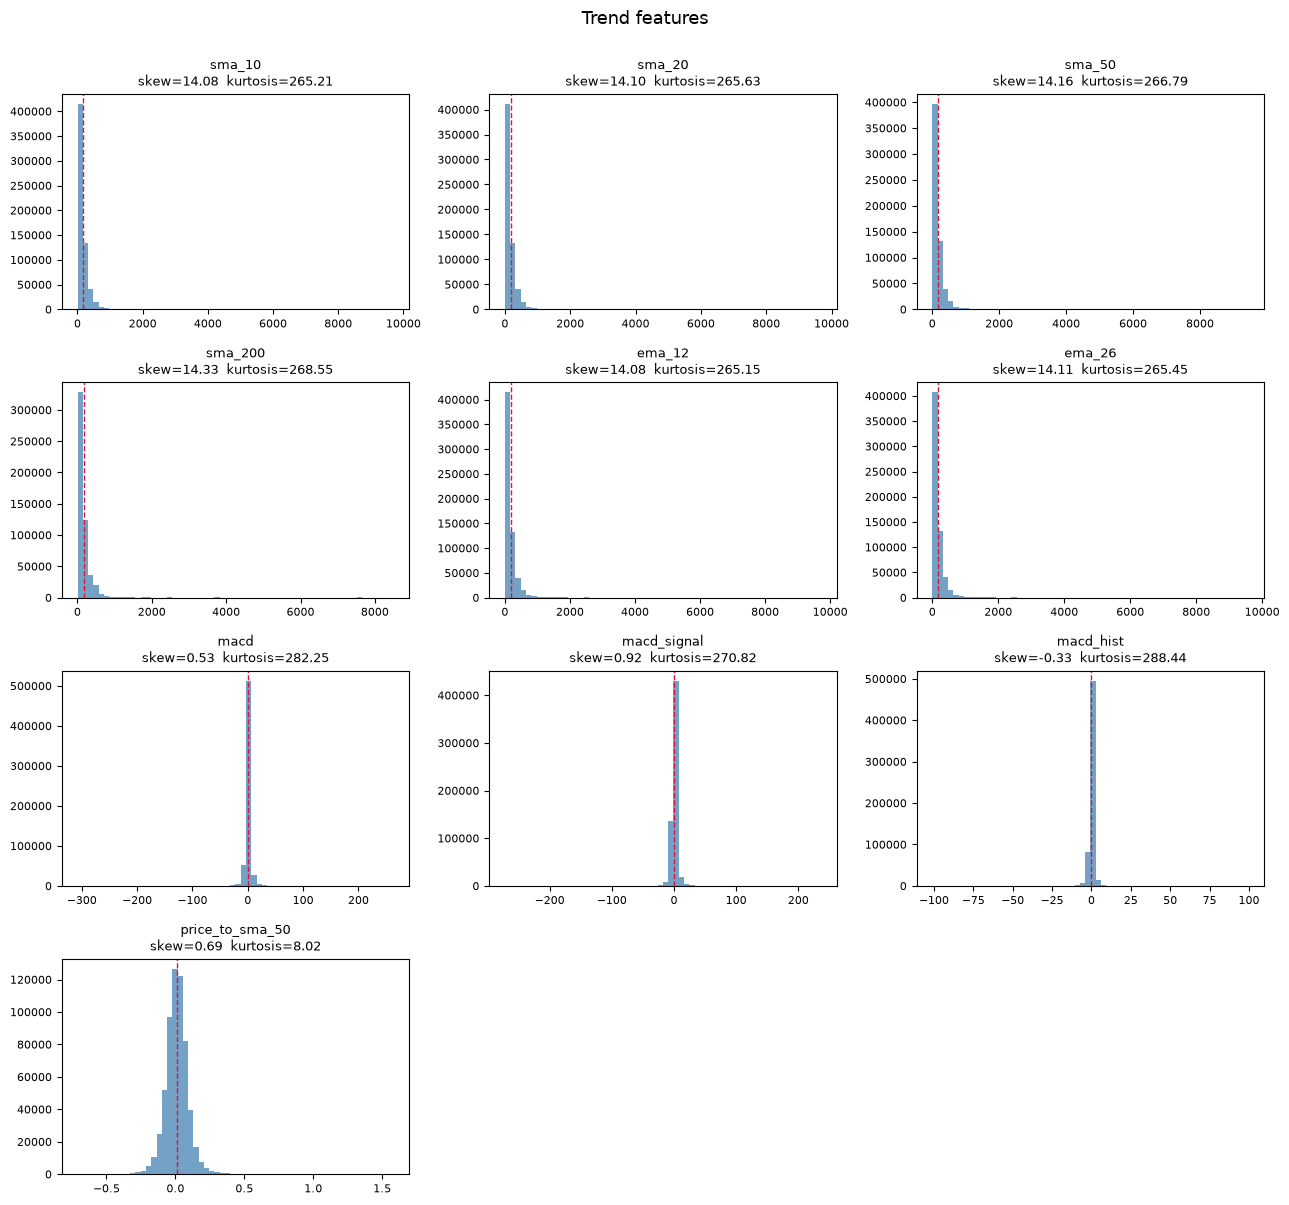

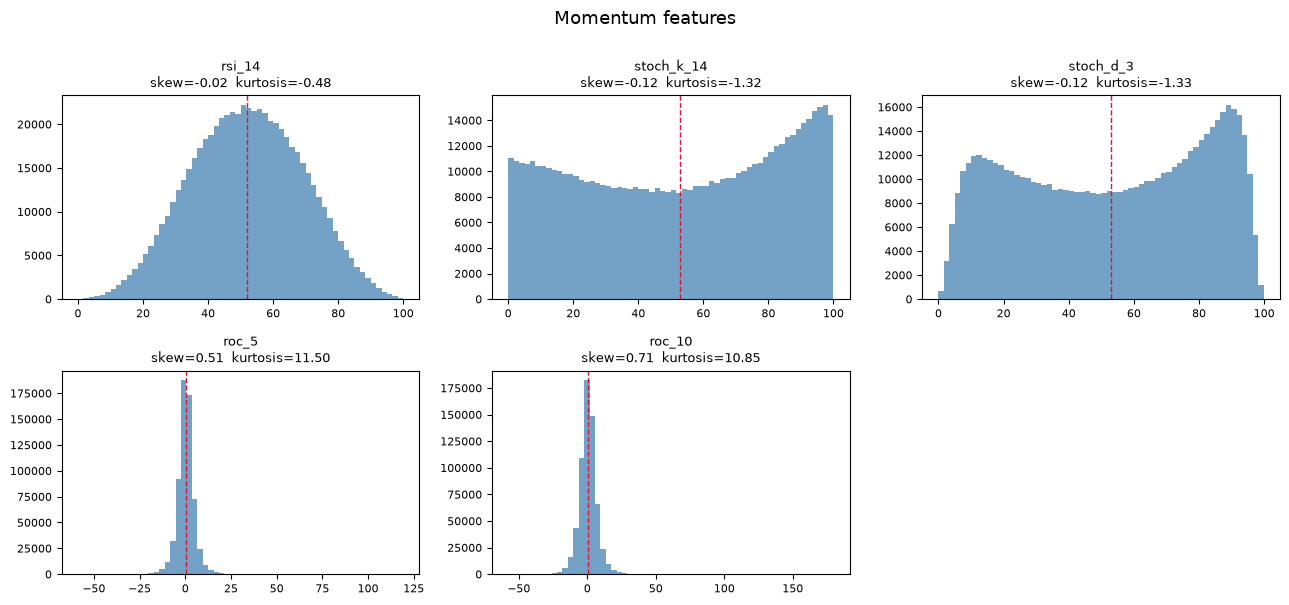

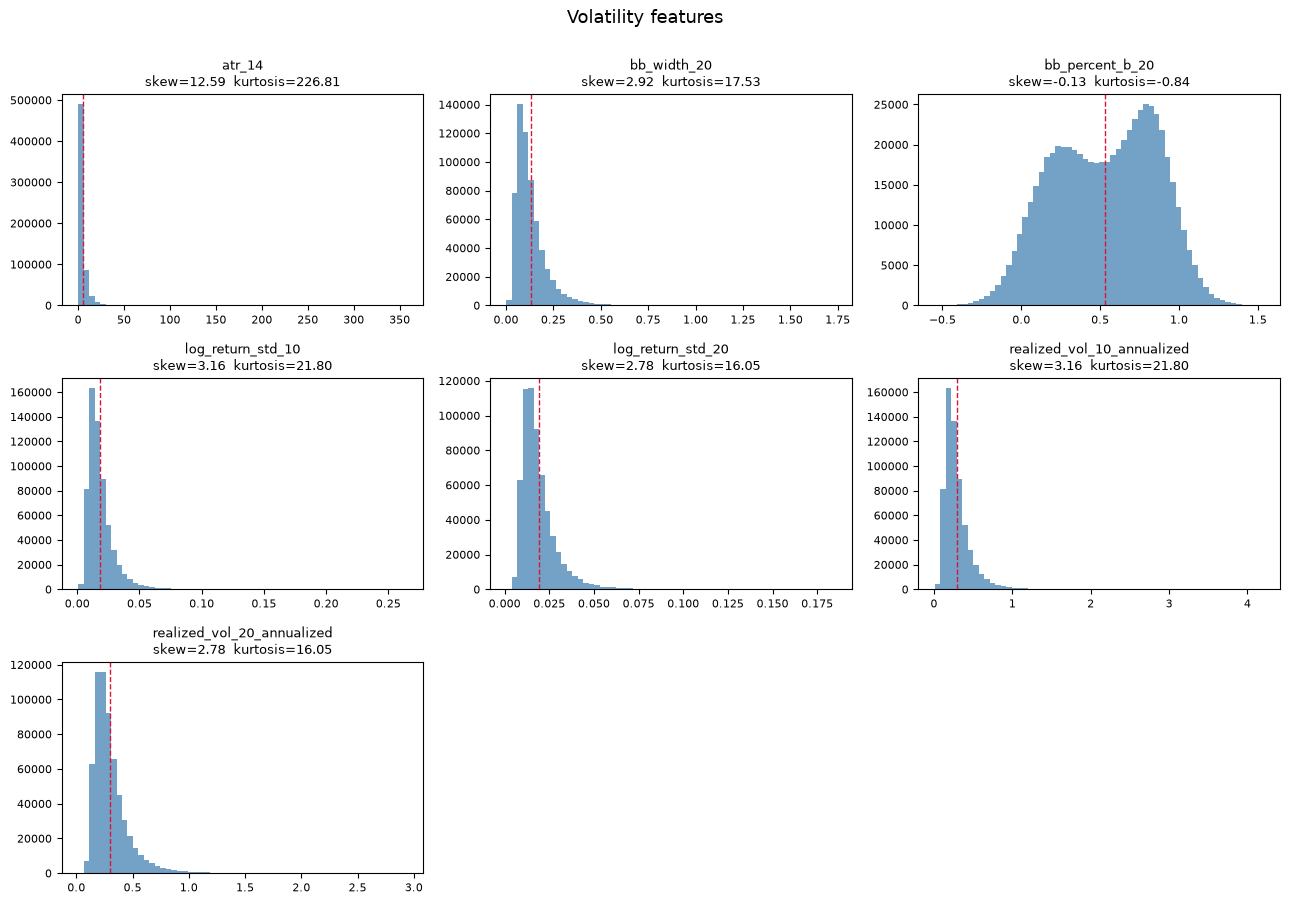

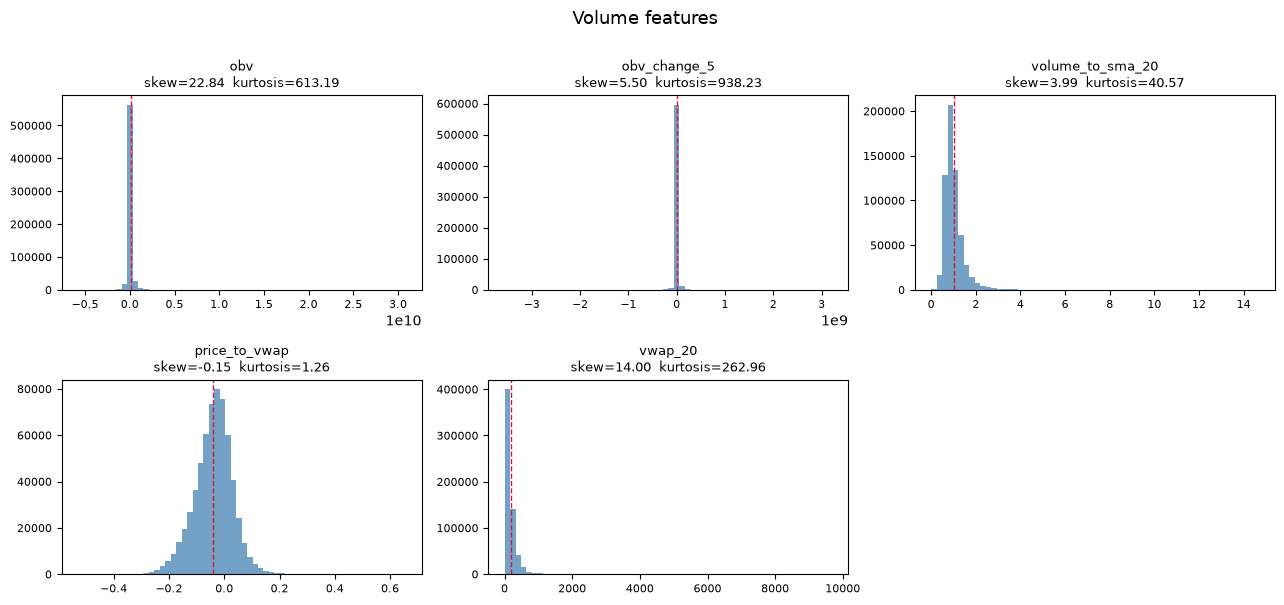

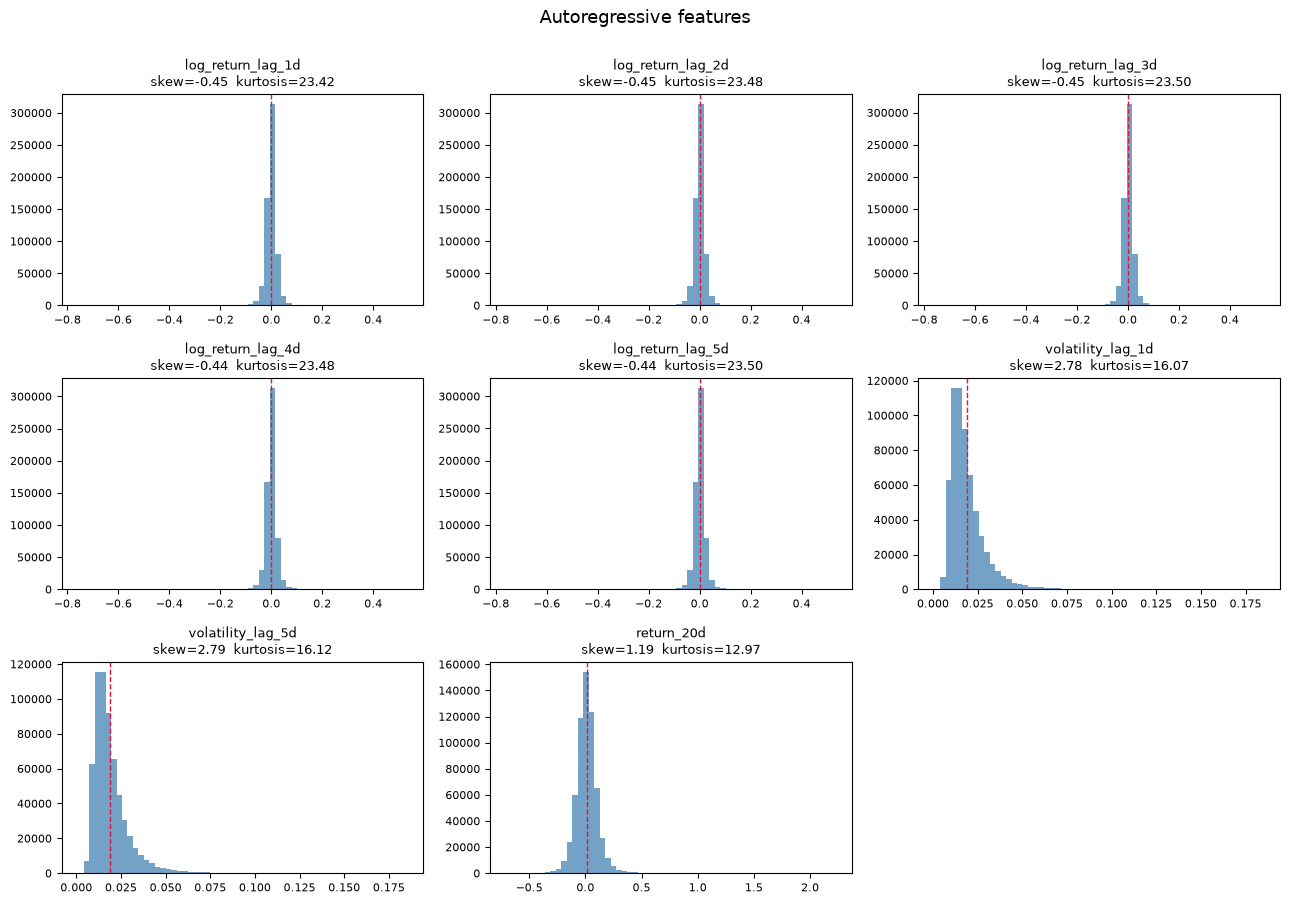

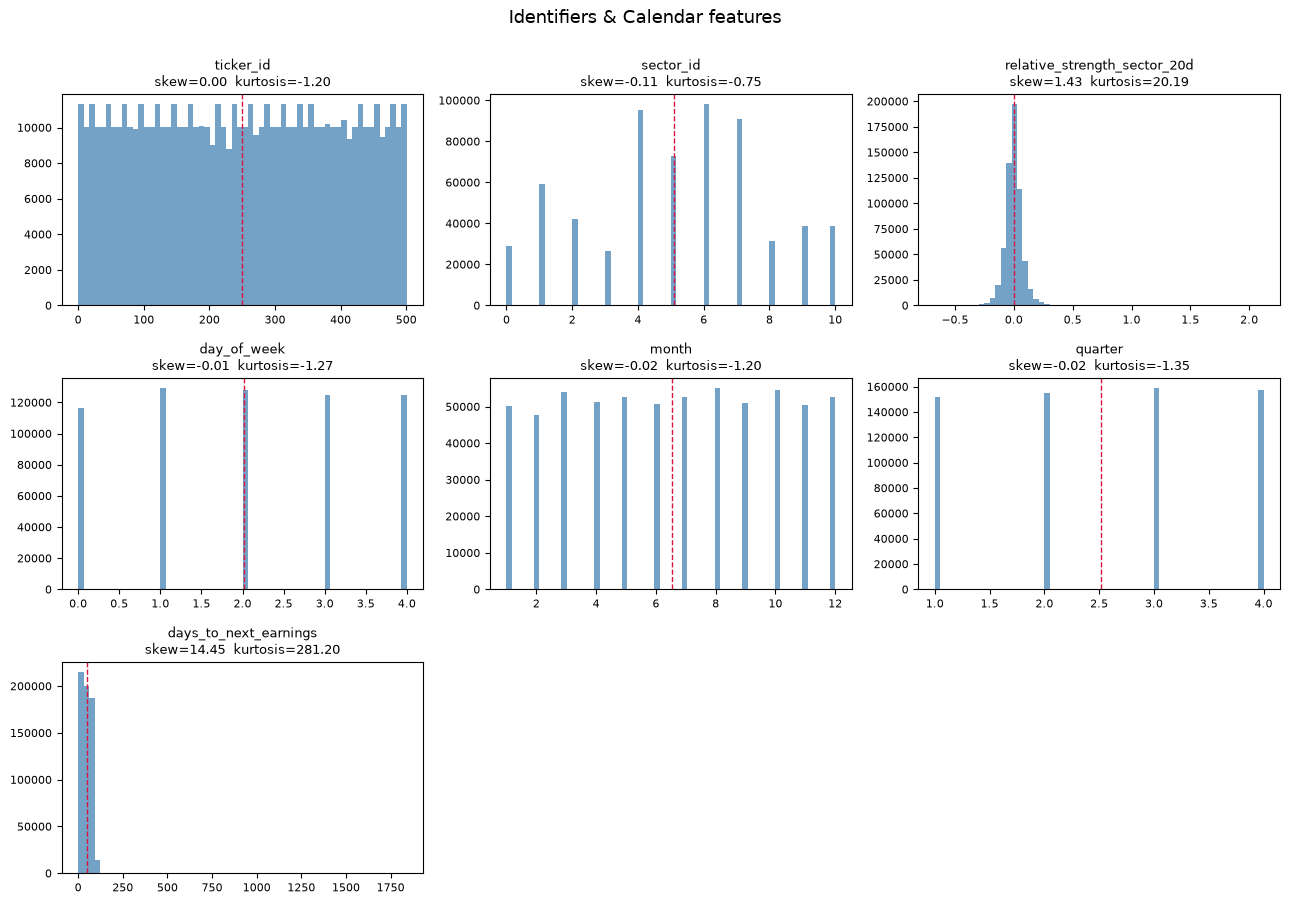

In [6]:
for family_name, columns in FEATURE_FAMILIES.items():
    plot_family_distributions(data, columns, family_name)

In [7]:
expected_ranges = {
    "rsi_14": (0, 100),
    "stoch_k_14": (0, 100),
    "stoch_d_3": (0, 100),
    "bb_percent_b_20": (-0.5, 1.5),
    "bb_width_20": (0, None),
    "atr_14": (0, None),
    "log_return_std_10": (0, None),
    "log_return_std_20": (0, None),
    "realized_vol_10_annualized": (0, None),
    "realized_vol_20_annualized": (0, None),
    "volume_to_sma_20": (0, None),
}

violations = []
for feature, (low, high) in expected_ranges.items():
    if feature not in data.columns:
        continue
    series = data[feature].dropna()
    below = int((series < low).sum()) if low is not None else 0
    above = int((series > high).sum()) if high is not None else 0
    if below or above:
        violations.append({
            "feature": feature,
            "expected": f"[{low}, {high}]",
            "below_min": below,
            "above_max": above,
            "observed_min": round(series.min(), 4),
            "observed_max": round(series.max(), 4),
        })

if violations:
    print("RANGE VIOLATIONS -- likely computation bugs in indicators.py:")
    display(pd.DataFrame(violations))
else:
    print("All bounded features are within their expected ranges.")

RANGE VIOLATIONS -- likely computation bugs in indicators.py:


,feature,expected,below_min,above_max,observed_min,observed_max
0,bb_percent_b_20,"[-0.5, 1.5]",23,34,-0.5485,1.536


In [8]:
def family_of(feature):
    for family, patterns in FEATURE_FAMILIES.items():
        if any(pattern in feature for pattern in patterns):
            return family
    return "other"


families = {}
for feature in features:
    families.setdefault(family_of(feature), []).append(feature)

for family, members in families.items():
    print(f"{family:16} {members}")

Trend            ['sma_10', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist', 'price_to_sma_50', 'volume_to_sma_20']
Momentum         ['rsi_14', 'stoch_k_14', 'stoch_d_3', 'roc_5', 'roc_10']
Volatility       ['atr_14', 'bb_width_20', 'bb_percent_b_20', 'log_return_std_10', 'log_return_std_20', 'realized_vol_10_annualized', 'realized_vol_20_annualized']
Volume           ['obv', 'obv_change_5', 'price_to_vwap', 'vwap_20']
Autoregressive   ['log_return_lag_1d', 'log_return_lag_2d', 'log_return_lag_3d', 'log_return_lag_4d', 'log_return_lag_5d', 'volatility_lag_1d', 'volatility_lag_5d', 'return_20d']
Identifiers & Calendar ['ticker_id', 'sector_id', 'relative_strength_sector_20d', 'day_of_week', 'month', 'quarter', 'days_to_next_earnings']


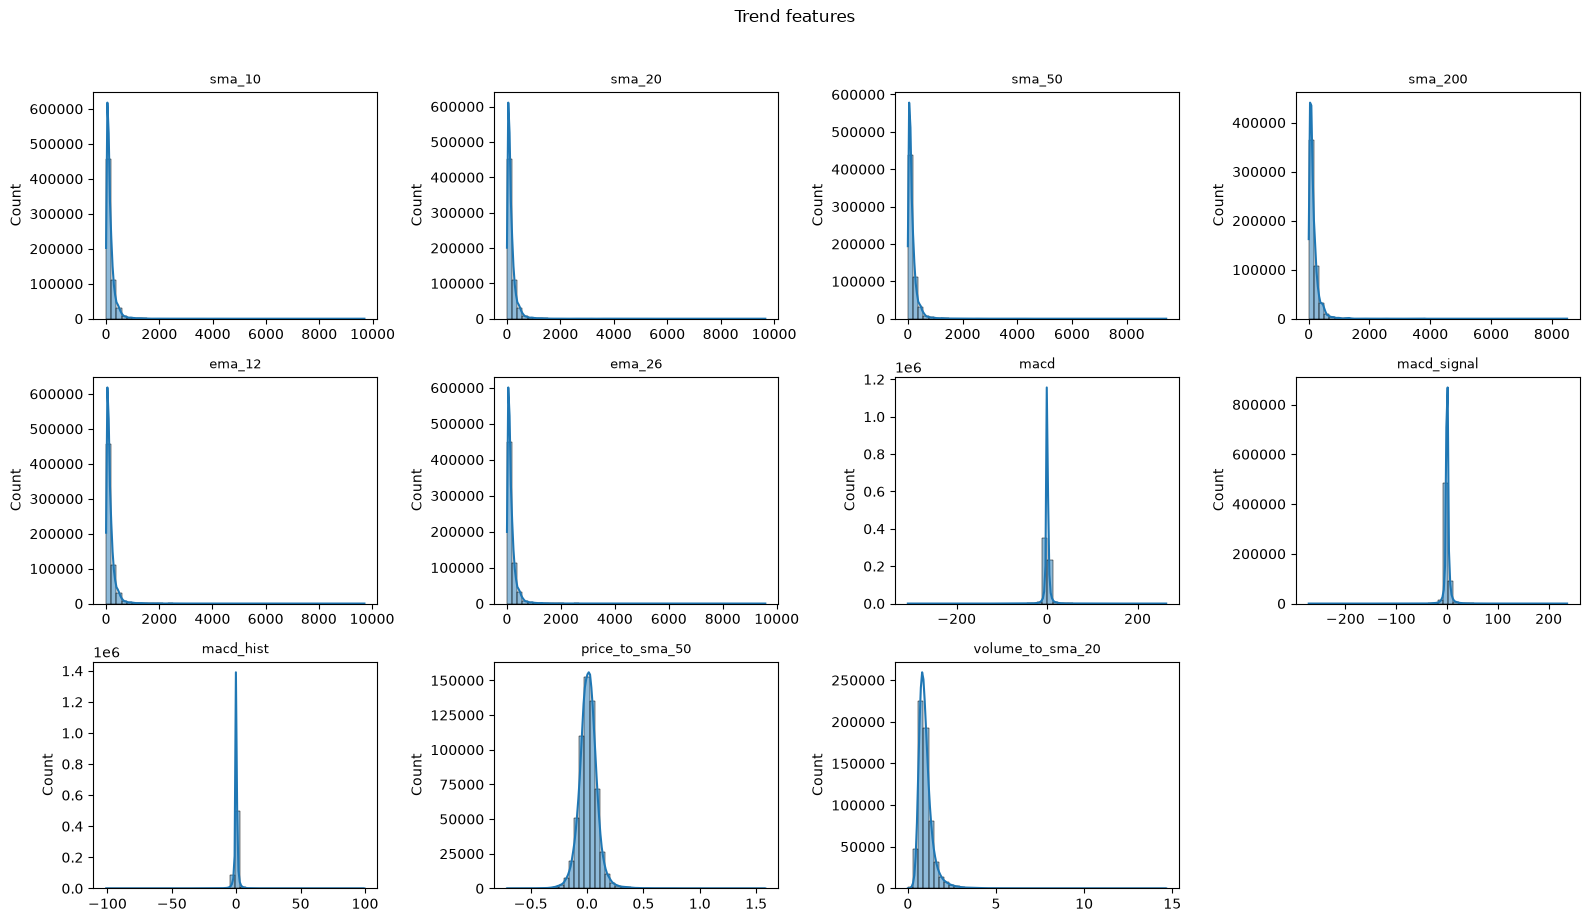

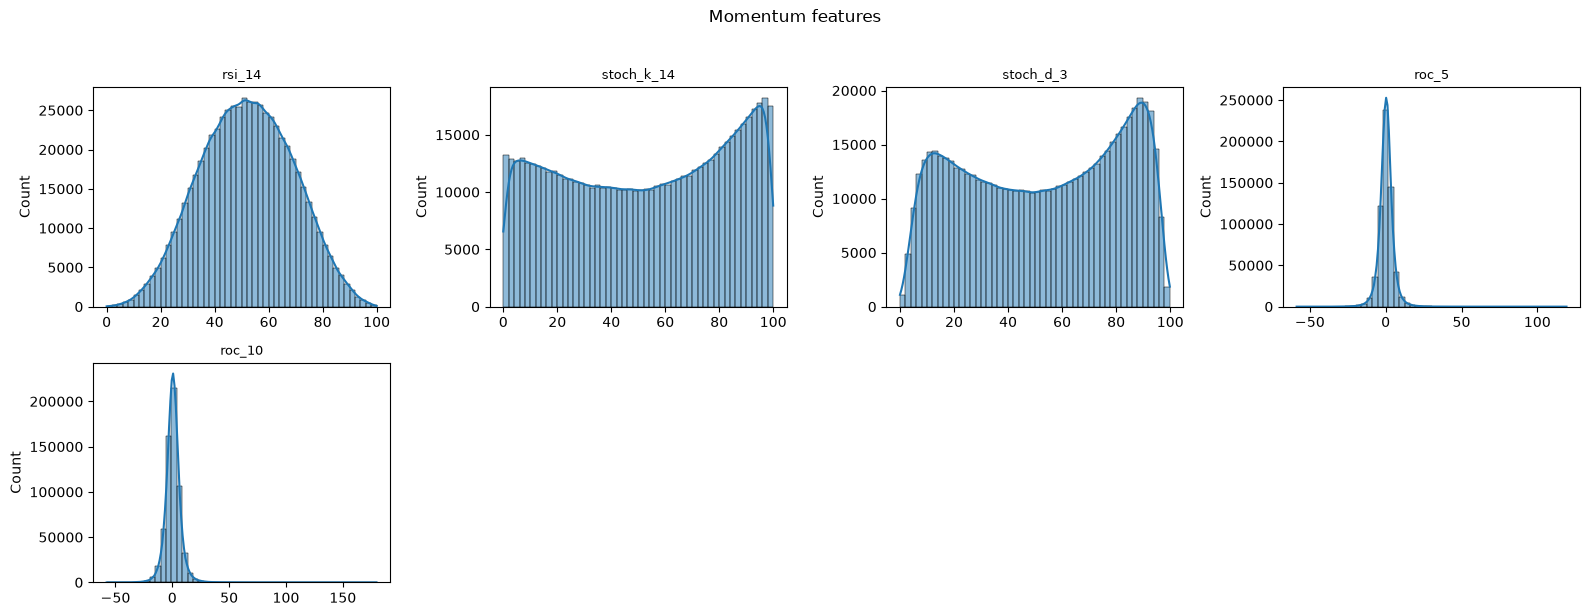

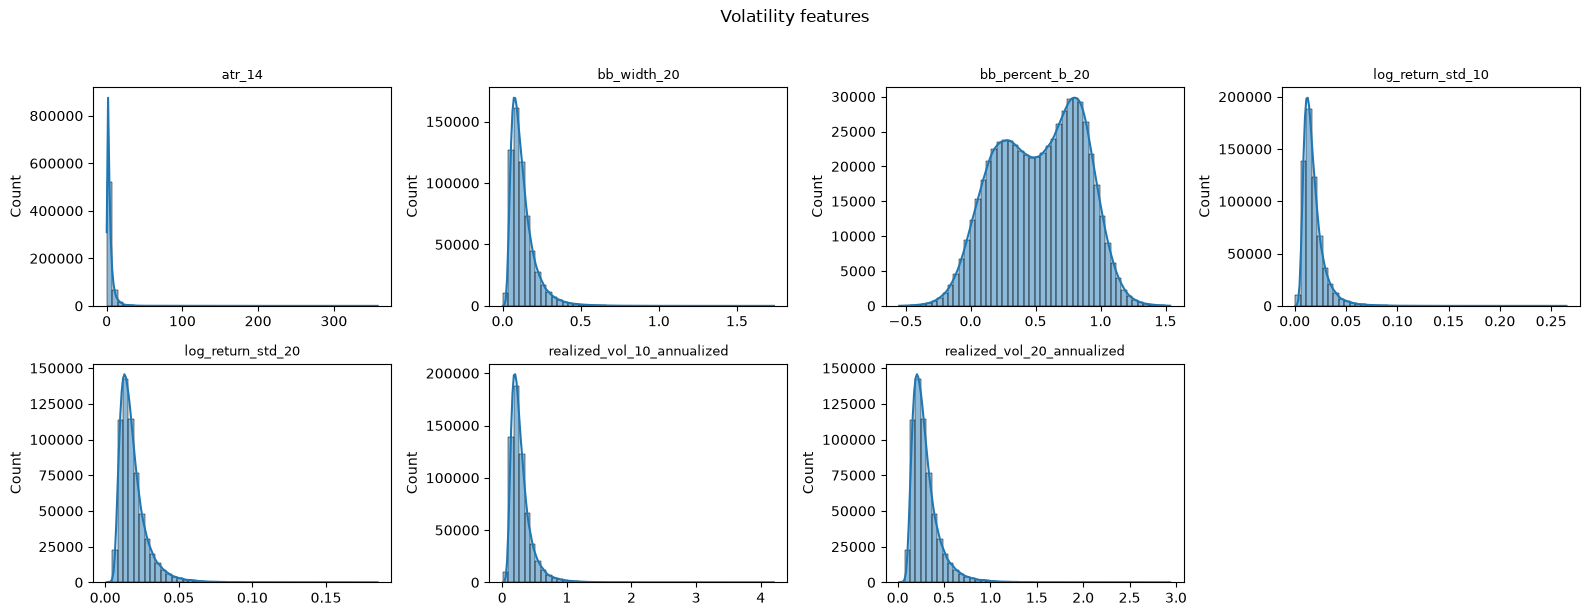

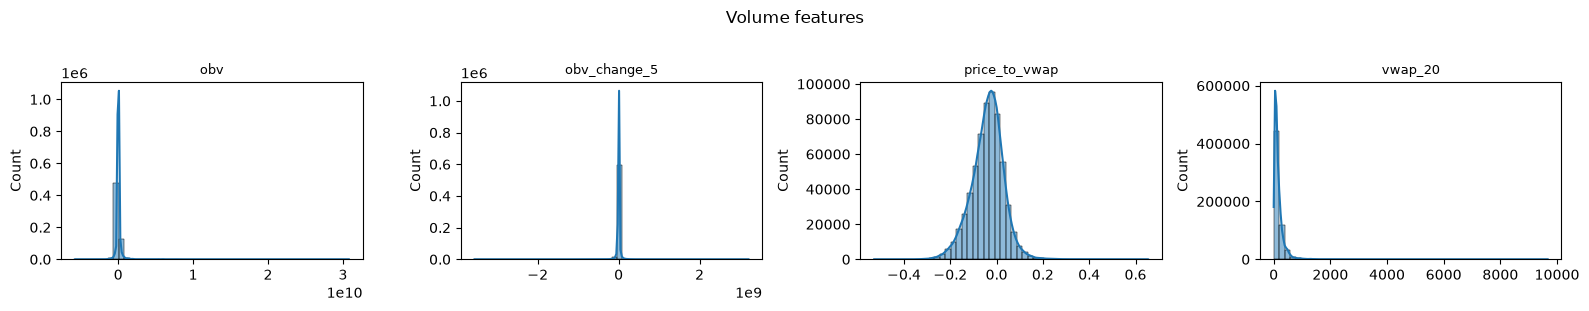

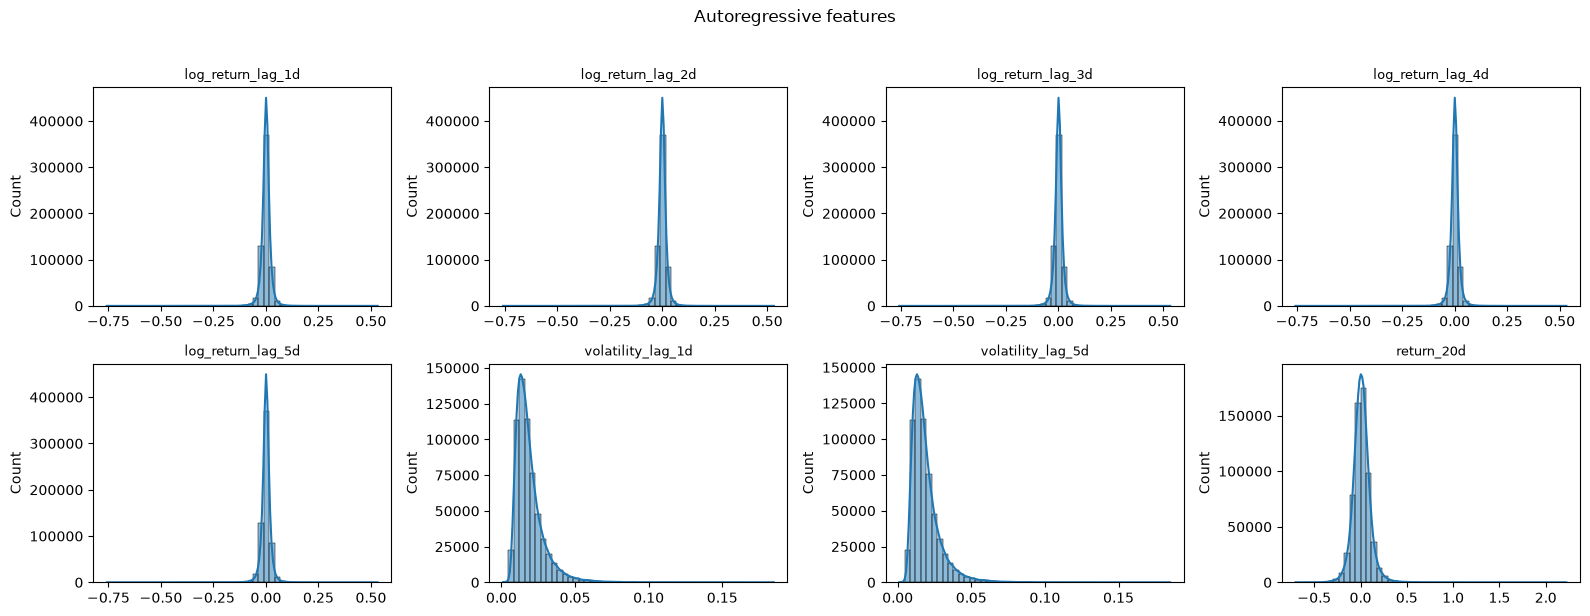

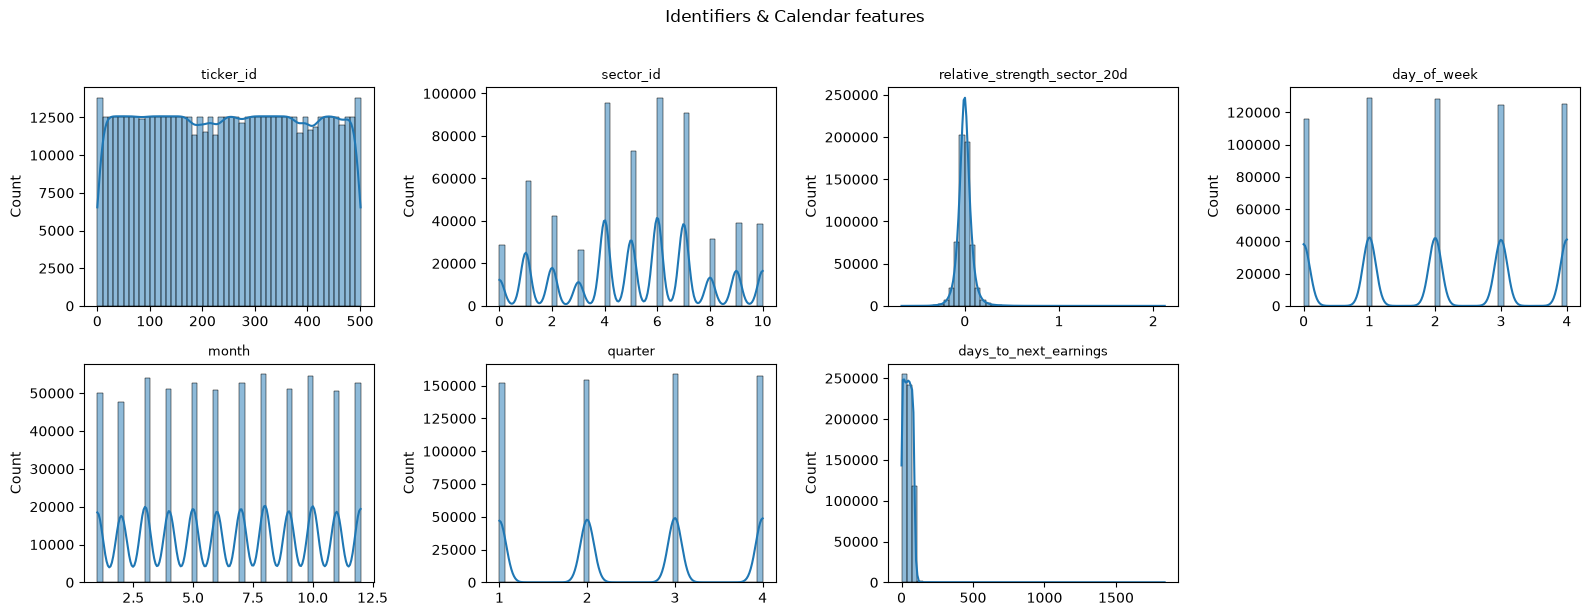

In [9]:
for family, members in families.items():
    n_cols = min(4, len(members))
    n_rows = int(np.ceil(len(members) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, feature in zip(axes, members):
        sns.histplot(data[feature].dropna(), bins=50, kde=True, ax=ax)
        ax.set_title(feature, fontsize=9)
        ax.set_xlabel("")

    for ax in axes[len(members):]:
        ax.axis("off")

    fig.suptitle(f"{family} features", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

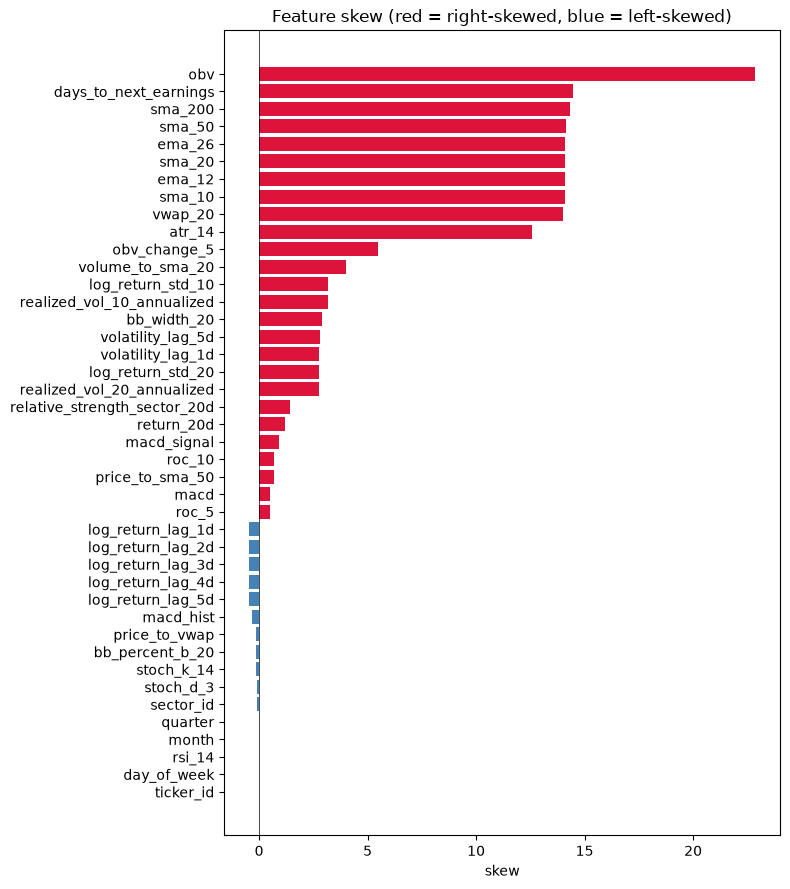

In [10]:
skew_table = (
    data[features].skew().rename("skew").to_frame()
    .assign(abs_skew=lambda d: d["skew"].abs())
    .sort_values("abs_skew", ascending=False)
    .drop(columns="abs_skew")
)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["crimson" if v > 0 else "steelblue" for v in skew_table["skew"]]
ax.barh(skew_table.index[::-1], skew_table["skew"][::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("skew")
ax.set_title("Feature skew (red = right-skewed, blue = left-skewed)")
plt.tight_layout()
plt.show()

In [11]:
bounded = {
    "rsi_14": (0, 100),
    "stoch_k_14": (0, 100),
    "stoch_d_3": (0, 100),
}

for column, (low, high) in bounded.items():
    if column not in data.columns:
        continue
    series = data[column].dropna()
    below = (series < low).sum()
    above = (series > high).sum()
    status = "OK" if (below == 0 and above == 0) else "OUT OF BOUNDS"
    print(f"{column:14} range [{series.min():.2f}, {series.max():.2f}]  "
          f"expected [{low}, {high}]  {status}")

# Non-negative features: volatility and range measures cannot be negative.
print()
non_negative = [
    "atr_14", "bb_width_20",
    "log_return_std_10", "log_return_std_20",
    "realized_vol_10_annualized", "realized_vol_20_annualized",
]
for column in non_negative:
    if column not in data.columns:
        continue
    minimum = data[column].min()
    status = "OK" if minimum >= 0 else "NEGATIVE -- bug"
    print(f"{column:28} min = {minimum:.5f}  {status}")

rsi_14         range [0.00, 99.97]  expected [0, 100]  OK
stoch_k_14     range [0.00, 100.00]  expected [0, 100]  OK
stoch_d_3      range [0.00, 99.86]  expected [0, 100]  OK

atr_14                       min = 0.05286  OK
bb_width_20                  min = 0.00264  OK
log_return_std_10            min = 0.00071  OK
log_return_std_20            min = 0.00103  OK
realized_vol_10_annualized   min = 0.01134  OK
realized_vol_20_annualized   min = 0.01630  OK


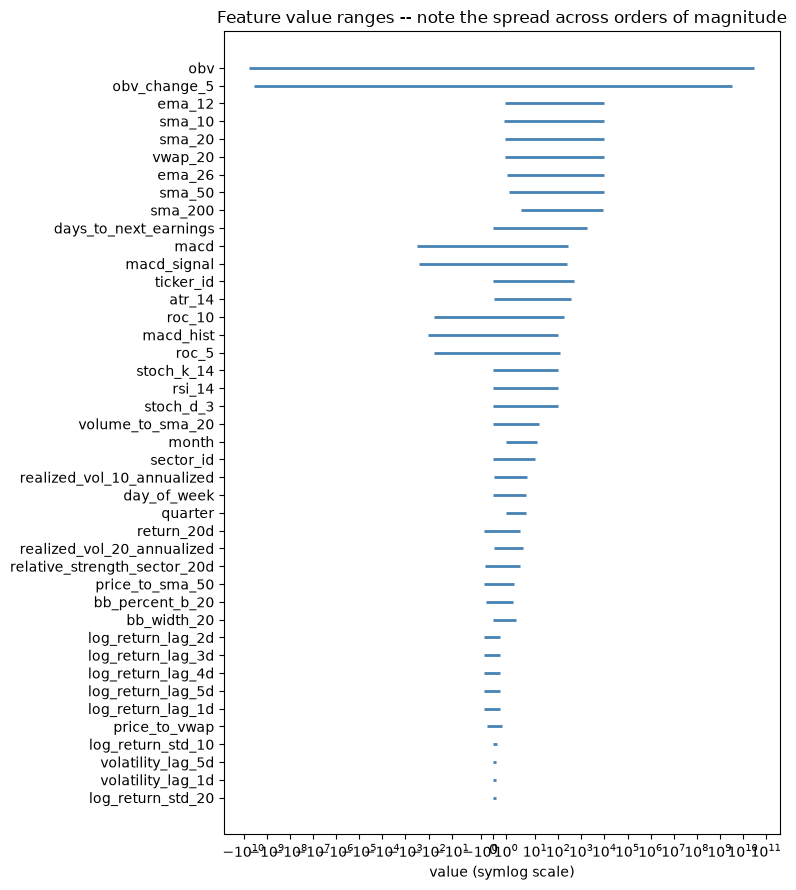

In [12]:
ranges = pd.DataFrame({
    "min": data[features].min(),
    "max": data[features].max(),
}).assign(span=lambda d: (d["max"] - d["min"]).abs()).sort_values("span")

fig, ax = plt.subplots(figsize=(8, 9))
ax.hlines(ranges.index, ranges["min"], ranges["max"], color="steelblue", lw=2)
ax.set_xscale("symlog")
ax.set_xlabel("value (symlog scale)")
ax.set_title("Feature value ranges -- note the spread across orders of magnitude")
plt.tight_layout()
plt.show()

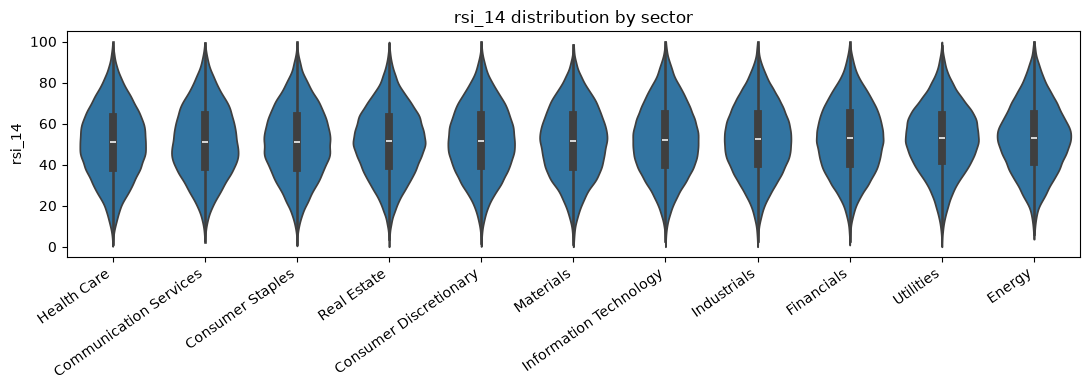

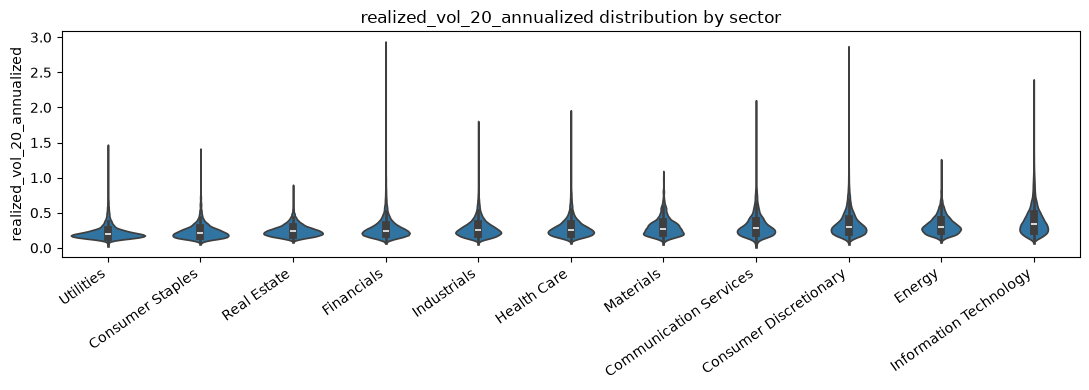

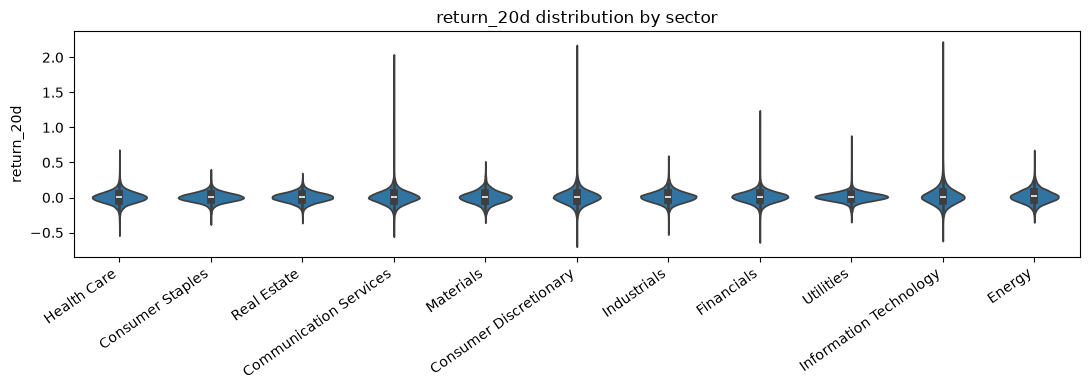

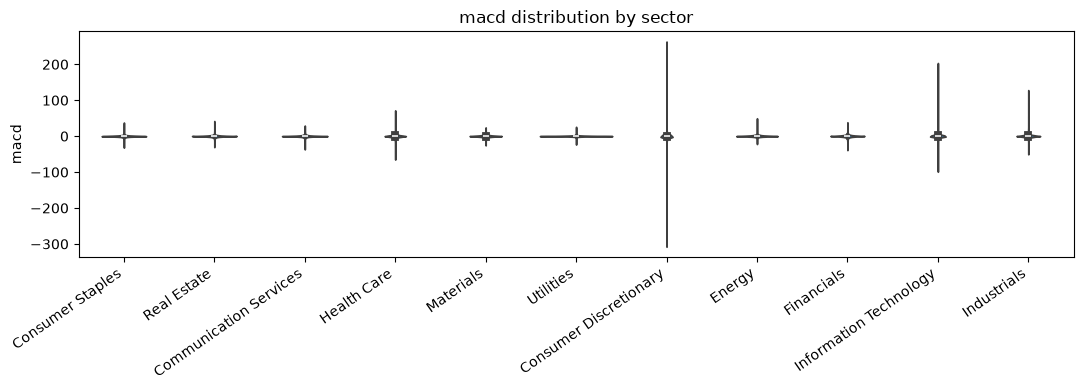

In [13]:
sector_features = [name for name in ["rsi_14", "realized_vol_20_annualized", "return_20d", "macd"]
                   if name in data.columns]

for feature in sector_features:
    fig, ax = plt.subplots(figsize=(11, 4))
    order = data.groupby("gics_sector")[feature].median().sort_values().index
    sns.violinplot(data=data, x="gics_sector", y=feature, order=order, ax=ax, cut=0)
    ax.set_title(f"{feature} distribution by sector")
    ax.set_xlabel("")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

In [14]:
records = []
for feature in features:
    series = data[feature].dropna()
    if series.nunique() < 3:
        continue
    statistic, p_value = stats.jarque_bera(series)[:2]
    records.append({
        "feature": feature,
        "jarque_bera": statistic,
        "p_value": p_value,
        "skew": series.skew(),
        "excess_kurtosis": series.kurtosis(),
    })

normality = pd.DataFrame(records).set_index("feature")
normality["normal_at_5pct"] = normality["p_value"] > 0.05
normality = normality.sort_values("excess_kurtosis", ascending=False)

print(f"features consistent with normality (p > 0.05): "
      f"{int(normality['normal_at_5pct'].sum())} of {len(normality)}")
display(normality.round(4))

features consistent with normality (p > 0.05): 0 of 42


,jarque_bera,p_value,skew,excess_kurtosis,normal_at_5pct
feature,,,,,
obv_change_5,2.273308e+10,0.0,5.4992,938.2337,False
obv,9.802089e+09,0.0,22.8383,613.1853,False
macd_hist,2.099567e+09,0.0,-0.3323,288.4386,False
macd,2.023722e+09,0.0,0.5256,282.2474,False
days_to_next_earnings,2.064994e+09,0.0,14.4548,281.1979,False
macd_signal,1.850997e+09,0.0,0.9221,270.8211,False
sma_200,1.588486e+09,0.0,14.3311,268.5464,False
sma_50,1.792475e+09,0.0,14.1626,266.7905,False
sma_20,1.821531e+09,0.0,14.1020,265.6271,False


In [15]:
SAMPLE_SYMBOLS = 10   # ADF per ticker; sample keeps this fast on the full panel


def adf_pvalue(series):
    series = series.dropna()
    if len(series) < 30 or series.nunique() < 3:
        return np.nan
    try:
        return adfuller(series, autolag="AIC")[1]
    except Exception:
        return np.nan


symbols = pd.Series(data["symbol"].unique()).head(SAMPLE_SYMBOLS)
results = {}
for symbol in symbols:
    group = data[data["symbol"] == symbol].sort_values("date")
    results[symbol] = {feature: adf_pvalue(group[feature]) for feature in features}

adf_by_symbol = pd.DataFrame(results)
stationarity = pd.DataFrame({
    "pct_tickers_stationary": (adf_by_symbol < 0.05).mean(axis=1) * 100,
    "median_adf_p": adf_by_symbol.median(axis=1),
}).sort_values("pct_tickers_stationary")

print(f"ADF run per feature across {len(symbols)} tickers.")
print("Low percentages = the feature drifts with price level (non-stationary):\n")
display(stationarity.round(3))

ADF run per feature across 10 tickers.
Low percentages = the feature drifts with price level (non-stationary):



,pct_tickers_stationary,median_adf_p
obv,0.0,0.521
ticker_id,0.0,NaN
sector_id,0.0,NaN
ema_26,10.0,0.592
vwap_20,10.0,0.615
ema_12,10.0,0.611
sma_200,20.0,0.379
sma_50,20.0,0.503
sma_10,20.0,0.570
sma_20,20.0,0.533


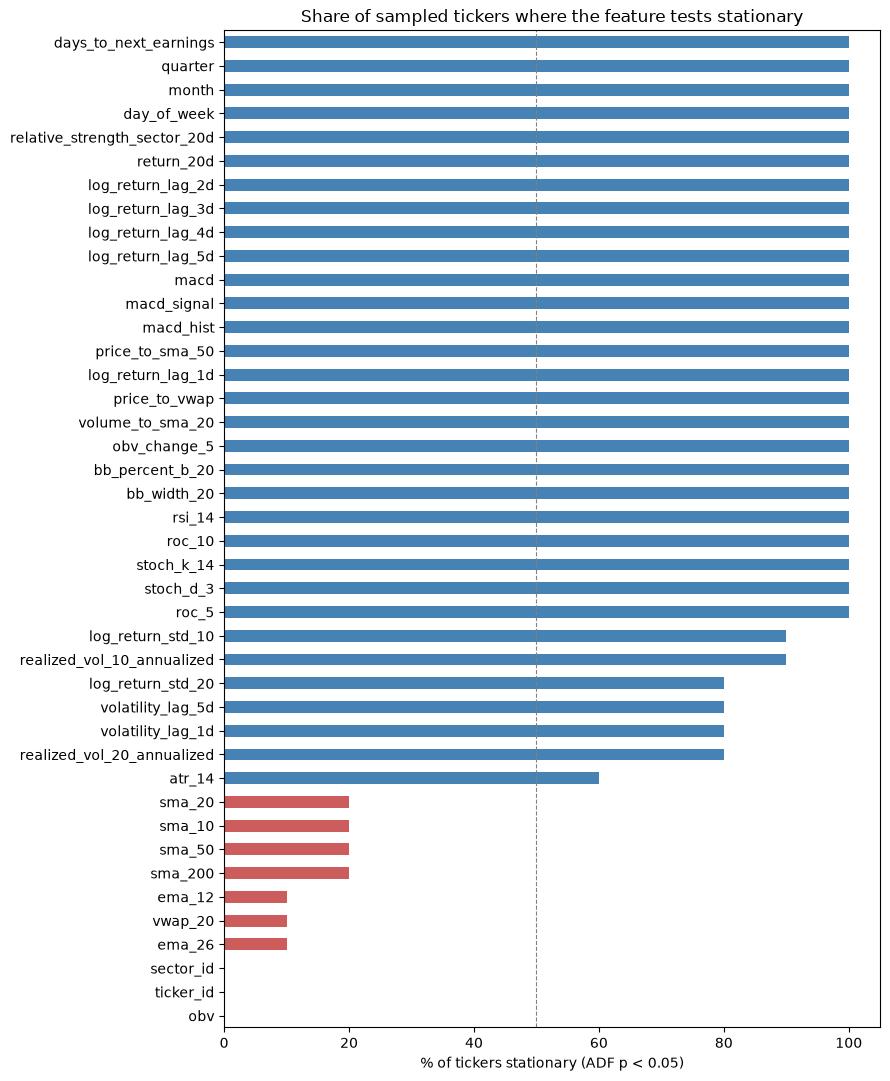

In [16]:
# Visual: which features are stationary across tickers. Bars near 100% are safely
# scale-free; bars near 0% carry the price level and may not generalise across time.
fig, ax = plt.subplots(figsize=(9, max(6, len(stationarity) * 0.26)))
colors = ["indianred" if value < 50 else "steelblue" for value in stationarity["pct_tickers_stationary"]]
stationarity["pct_tickers_stationary"].plot.barh(ax=ax, color=colors)
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Share of sampled tickers where the feature tests stationary")
ax.set_xlabel("% of tickers stationary (ADF p < 0.05)")
plt.tight_layout()
plt.show()

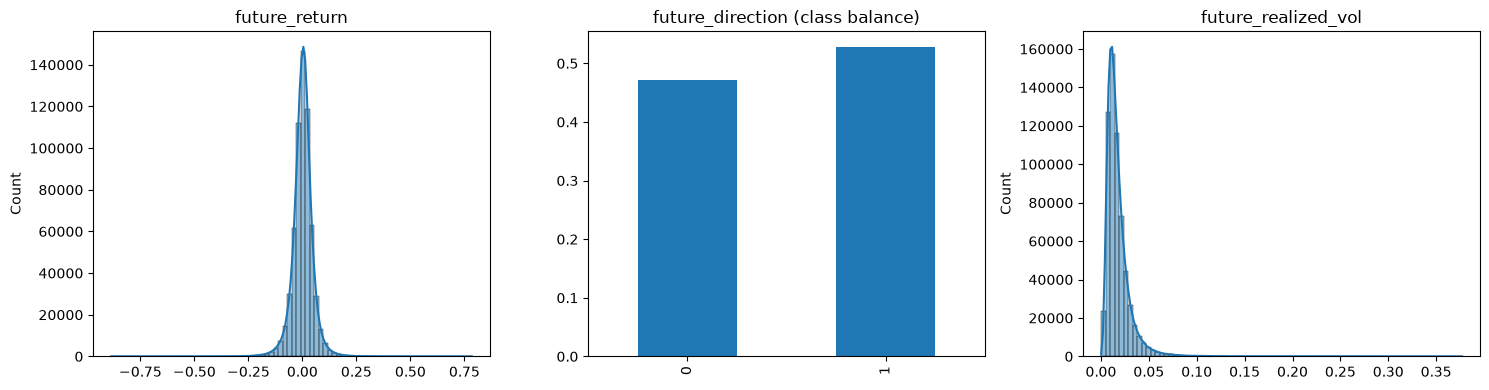

In [17]:
fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 4))
axes = np.atleast_1d(axes)

for ax, target in zip(axes, targets):
    series = data[target].dropna()
    if data[target].nunique(dropna=True) <= 3:
        series.value_counts(normalize=True).sort_index().plot.bar(ax=ax)
        ax.set_title(f"{target} (class balance)")
    else:
        sns.histplot(series, bins=80, kde=True, ax=ax)
        ax.set_title(f"{target}")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## Observations

- **Any range violations?** (computation bugs to fix in `indicators.py`)
- **Features with odd shapes** (spike-at-zero, near-constant, unexpected skew):
- **Features that differ strongly by sector** (justify keeping `sector_id`):
- **Features that look near-useless** (single value, no spread — candidates to drop):
- **Target spread and direction balance:**